In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [5]:
df = pd.read_csv("/Users/duncanmuir/Desktop/pinney_lab/code/data/20220412_adk_nadph_kinetics.csv", header=0)

In [6]:
df.head()

,Cycle Nr.,Time [s],Temp. [°C],B1,B2,B3,B4,B5,B6,B7,...,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18
0,1,0.000,29.6,18319,14656,9035,8338,6063,6719,4912,...,2850,2806,2553,2820,2559,2763,2803,2636,3883,852
1,2,23.782,29.8,18571,14661,9049,8431,6089,6856,4908,...,2866,2856,2588,2867,2588,2800,2793,2625,3894,876
2,3,47.081,29.8,18444,14871,9116,8758,6191,6799,4996,...,2898,2899,2604,2871,2602,2792,2819,2623,3903,870
3,4,70.382,29.7,18620,14982,9354,8779,6292,6989,5013,...,2969,2898,2584,2861,2600,2773,2811,2625,3936,879
4,5,93.682,29.7,18739,15122,9440,8953,6348,7003,5067,...,2945,2917,2571,2905,2598,2807,2843,2650,3937,899


In [48]:
bs_df = df.iloc[:, 3:21].T

In [41]:
times = np.tile(df["Time [s]"], (18,1))

In [32]:
times

(18, 309)

In [34]:
 bs_df.iloc[:6].T.shape

(18, 6)

In [42]:
bs_df.T.shape
times.shape

(18, 309)

In [55]:
bs_arr = np.array(bs_df)

Text(0, 0.5, 'RFU')

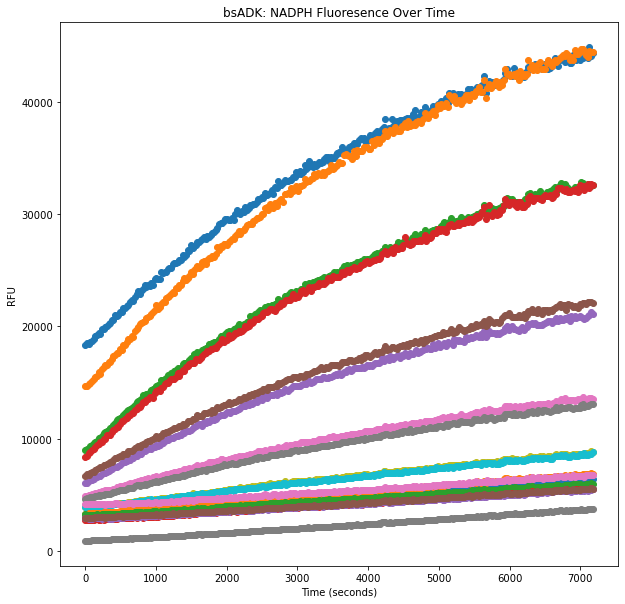

In [272]:
fig = plt.figure(figsize=(10,10))
for rfu, time in zip(np.array(bs_df), times):
    plt.scatter(time, rfu)
    
plt.title("bsADK: NADPH Fluoresence Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("RFU")

## Get Initial Rate

Text(0, 0.5, 'RFU')

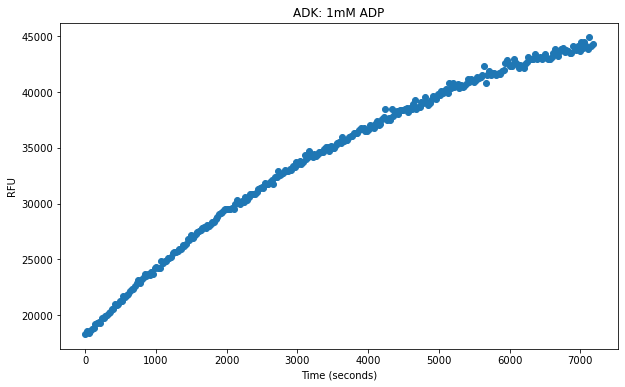

In [110]:
fig = plt.figure(figsize=(10,6))

plt.scatter(times[0], bs_arr[0])
plt.title("ADK: 1mM ADP")
plt.xlabel("Time (seconds)")
plt.ylabel("RFU")

## Determining Which Data to Use/Include
From the NADPH Std Curve we have a relationship as follows:  
179 RFU per 1µM NADPH 

Given the reaction:   
    2ADP <-> AMP + ATP  
And that 1 ATP goes on to produce 1 NADPH: 

At our top concentration of substrate (1 mM ADP), our coupled reaction could produce maximally **500 µM NADPH**

So we would want to only included data up to 50 µM NADPH.

This would equate to 8950 RFUs. However, due to dead time and some potential volume/tape related artifacts, we can think of only inlcluding a conservative window of a ∆RFU = 8950 RFU.
More clearly:  
I plan to compute an initial slope from 5% of the data, and then determine a time frame for which 8950 RFUs would be produced.
This time frame will then conservatively clipped to 75% of the determined time frame to account for dead time.

_**Note**_:  
If we assume that the baseline is not shifted due to some artifact, the baseline could be extrapolated back to zero, but that likely would not work with the first few bs_ADK samples

In [179]:
# 1mM ADP Replicate one data
time_arr = times[0]
rfu_arr = bs_arr[0]
prod_arr = rfu_arr / 179

In [180]:
init_percentile = 5

In [181]:
init_window = int(prod_arr.shape[0] // (100 / init_percentile))

In [183]:
init_reg = LinearRegression().fit(time_arr[:init_window].reshape(-1,1), prod_arr[:init_window])

In [184]:
init_slope = init_reg.coef_.item()
print(f"initial slope: {init_slope:.3f} µM / s")

initial slope: 0.033 µM / s


Given this slope, we can say that roughly 10% of product would be formed in:

In [185]:
ten_percent_time = 50 / init_slope
print(f"{ten_percent_time:.3f} seconds")

1526.252 seconds


Now we can apply some conservative cutoff to account for deadtime

In [186]:
cutoff = 0.75
adjusted_time = cutoff * ten_percent_time

In [190]:
initial_rate_idxs = np.where(time_arr <= adjusted_time)
initial_rate_times = time_arr[initial_rate_idxs]
initial_rate_prods = prod_arr[initial_rate_idxs]

In [191]:
initial_rate_reg = LinearRegression().fit(initial_rate_times.reshape(-1, 1), initial_rate_prods)
initial_rate_slope = initial_rate_reg.coef_.item()
initial_rate_int = initial_rate_reg.intercept_.item()

In [192]:
print(f"Initial rate slope: {initial_rate_slope:.3f}")
print(f"Initial rate intercept: {initial_rate_int:.3f}")
print(f"Initial rate fit: {initial_rate_reg.score(initial_rate_times.reshape(-1, 1), initial_rate_prods):.3f}")

Initial rate slope: 0.033
Initial rate intercept: 102.249
Initial rate fit: 0.994


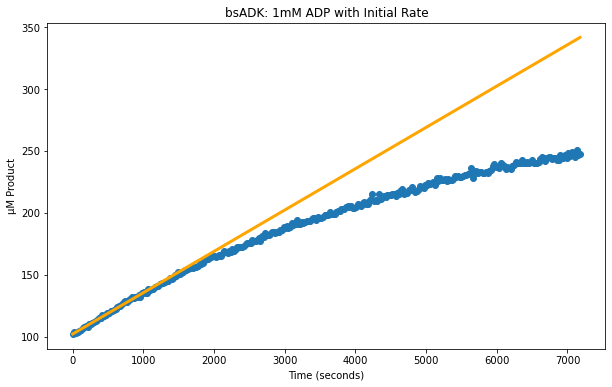

In [196]:
fig = plt.figure(figsize=(10,6))

plt.scatter(time_arr, prod_arr)
plt.title("bsADK: 1mM ADP with Initial Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("µM Product")

x = np.linspace(min(time_arr), max(time_arr), 1000)
plt.plot(x, x*initial_rate_slope + initial_rate_int,c="orange", linewidth=3)

## Wrapping Initial Slope into a Function

In [268]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array, 
                                   substrate_conc: float,
                                   product_stoichiometry: float,
                                   init_percentile: float = 0.05,
                                   conservative_cutoff: float = 0.75,
                                   max_reaction_progress: float = .10): 
    
    # get length of window to get estimate of initial rate
    init_window = int(signal_arr.shape[0] * init_percentile)
    
    init_reg = LinearRegression().fit(time_arr[:init_window].reshape(-1,1), signal_arr[:init_window])
    
    init_slope = init_reg.coef_.item()
    
    allowed_product_formation_conc = substrate_conc * product_stoichiometry * max_reaction_progress
    
    conservative_allowed_product_value = conservative_cutoff * allowed_product_formation_conc

    cutoff_time = conservative_allowed_product_value / init_slope
    print(cutoff_time)
    initial_rate_idxs = np.where(time_arr <= cutoff_time)
    initial_rate_times = time_arr[initial_rate_idxs]
    initial_rate_signals = signal_arr[initial_rate_idxs]
    
    initial_rate_reg = LinearRegression().fit(initial_rate_times.reshape(-1, 1), initial_rate_signals)
    initial_rate_slope = initial_rate_reg.coef_.item()
    initial_rate_int = initial_rate_reg.intercept_.item()
    initial_rate_score = initial_rate_reg.score(initial_rate_times.reshape(-1, 1), initial_rate_signals)
    return initial_rate_slope, initial_rate_int, initial_rate_score

In [205]:
compute_initial_reaction_slope(time_arr, prod_arr, 1000, .5, 179)

(0.03148011126027495, 103.15850239342144, 0.996738788628061)

# Applying New Function to bsADK Data

In [54]:
sub_concs = [1000, 500, 250, 125, 62.5, 31.25, 15.625, 7.8125]

In [207]:
bs_rep_1_arr = bs_arr[0::2] / 179

In [277]:
print(len(list(zip(bs_rep_1_arr, sub_concs))))

8


In [274]:
bs_rep_1_arr.shape

(9, 309)

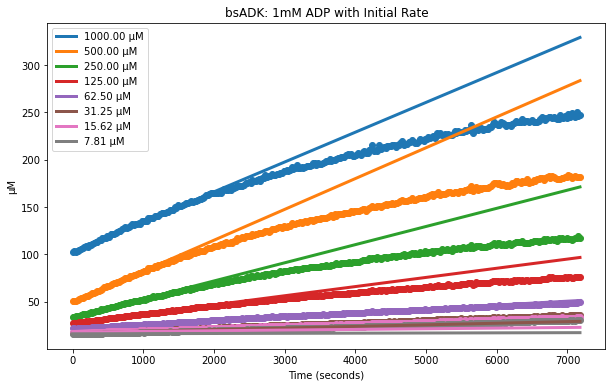

In [237]:
fig = plt.figure(figsize=(10,6))
    
for rep, sub_conc in zip(bs_rep_1_arr, sub_concs):
    slope, intercept, score = compute_initial_reaction_slope(time_arr, rep, sub_conc, .5, 179)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("bsADK: 1mM ADP with Initial Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

## Looking closer at initial rate fits

611.6136673364812
437.4298246171588
263.1428812549392
142.00721491277875


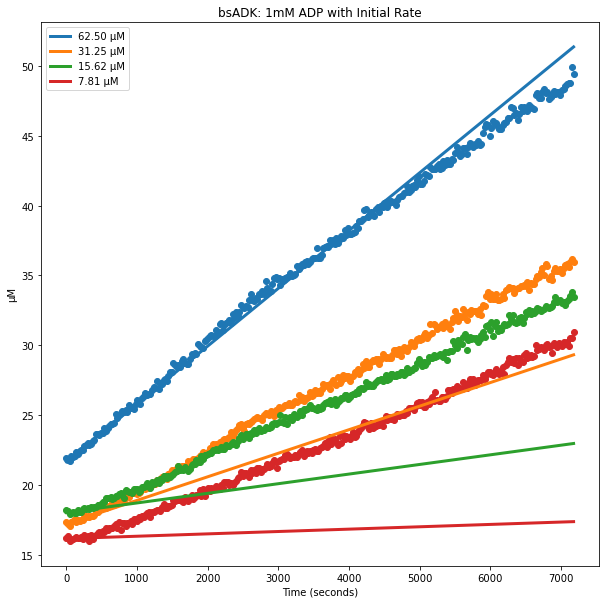

In [269]:
fig = plt.figure(figsize=(10,10))
    
for rep, sub_conc in zip(bs_rep_1_arr[4:], sub_concs[4:]):
    slope, intercept, score = compute_initial_reaction_slope(time_arr, rep, sub_conc, .5, 179)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("bsADK: 1mM ADP with Initial Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

^^^ This fitting method really falls apart at low substrate conc

## Rewriting intial reaction slope functionality
Really we only need the time window from the top substrate concentration, so once the window is determined for top conc, it is passed to the rest

In [247]:
def compute_initial_reaction_slope2(time_arr: np.array, 
                                     signal_arr: np.array,
                                     cutoff_time: float): 
    
    initial_rate_idxs = np.where(time_arr <= cutoff_time)
    initial_rate_times = time_arr[initial_rate_idxs]
    initial_rate_signals = signal_arr[initial_rate_idxs]
    
    initial_rate_reg = LinearRegression().fit(initial_rate_times.reshape(-1, 1), initial_rate_signals)
    initial_rate_slope = initial_rate_reg.coef_.item()
    initial_rate_int = initial_rate_reg.intercept_.item()
    initial_rate_score = initial_rate_reg.score(initial_rate_times.reshape(-1, 1), initial_rate_signals)
    return initial_rate_slope, initial_rate_int, initial_rate_score

In [241]:
def get_cutoff_time(time_arr: np.array, 
                   signal_arr: np.array, 
                   substrate_conc: float,
                   product_stoichiometry: float,
                   init_percentile: float = 0.05,
                   conservative_cutoff: float = 0.75,
                   max_reaction_progress: float = .10,
                   cutoff_time: int = None):
    # get length of window to get estimate of initial rate
    init_window = int(signal_arr.shape[0] * init_percentile)

    init_reg = LinearRegression().fit(time_arr[:init_window].reshape(-1,1), signal_arr[:init_window])

    init_slope = init_reg.coef_.item()

    allowed_product_formation_conc = substrate_conc * product_stoichiometry * max_reaction_progress

    conservative_allowed_product_value = conservative_cutoff * allowed_product_formation_conc

    cutoff_time = conservative_allowed_product_value / init_slope
    
    return cutoff_time

In [251]:
bs_1mm_cutoff = get_cutoff_time(time_arr, bs_rep_1_arr[0], 1000, .5)

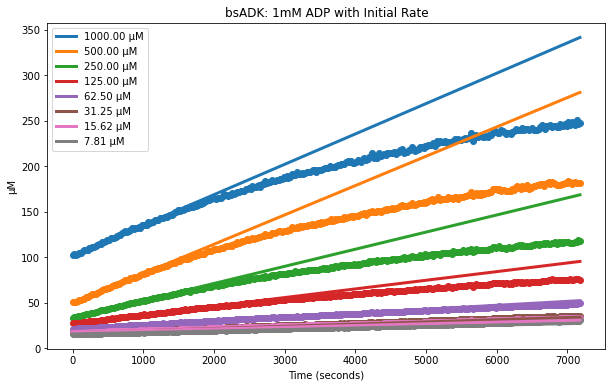

In [248]:
fig = plt.figure(figsize=(10,6))

cutoff_window = None
for rep, sub_conc in zip(bs_rep_1_arr, sub_concs):
    if cutoff_window is None:
        cutoff_window = get_cutoff_time(time_arr, rep, sub_conc, .5)
    slope, intercept, score = compute_initial_reaction_slope2(time_arr, rep, cutoff_window)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("bsADK: 1mM ADP with Initial Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

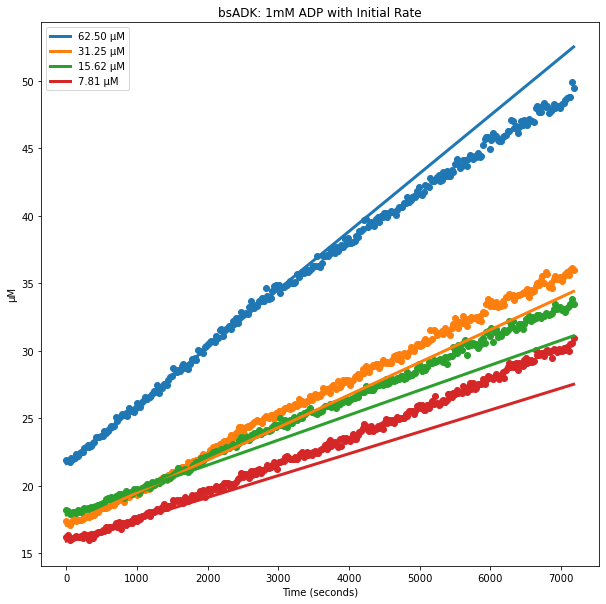

In [252]:
fig = plt.figure(figsize=(10,10))

cutoff_window = None
for rep, sub_conc in zip(bs_rep_1_arr[4:], sub_concs[4:]):
   
    slope, intercept, score = compute_initial_reaction_slope2(time_arr, rep, bs_1mm_cutoff)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("bsADK: 1mM ADP with Initial Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

# Micheaelis Menten for bsADK

In [209]:
bs_adk_rep_1_slopes = []
bs_adk_rep_2_slopes = []

for rep, sub_conc in zip(bs_arr[0::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope(time_arr, rep, sub_conc, .5, 179)
    bs_adk_rep_1_slopes.append(slope)

for rep, sub_conc in zip(bs_arr[1::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope(time_arr, rep, sub_conc, .5, 179)
    bs_adk_rep_2_slopes.append(slope)

In [210]:
bs_adk_avg_slopes = np.mean([bs_adk_rep_1_slopes, bs_adk_rep_2_slopes], axis=0)
errs = np.std([bs_adk_rep_1_slopes, bs_adk_rep_2_slopes], axis=0)

Text(0, 0.5, 'v (µM/s)')

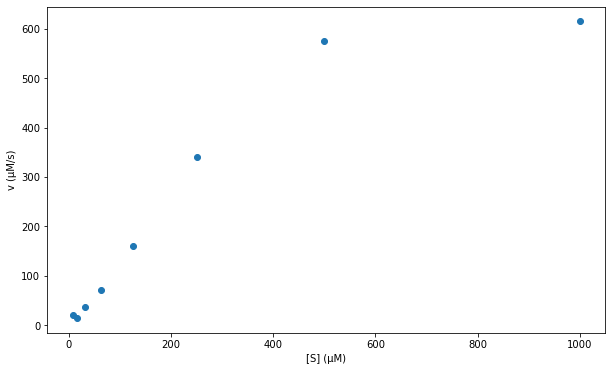

In [278]:
plt.figure(figsize=(10,6))
plt.scatter(sub_concs, np.array(bs_adk_avg_slopes) / e_conc)
plt.xlabel("[S] (µM)")
plt.ylabel("v (µM/s)")

In [214]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [215]:
from scipy.optimize import curve_fit

In [216]:
params, _ = curve_fit(mm_model, sub_concs, bs_adk_avg_slopes)

Text(0, 0.5, 'v (µM/s)')

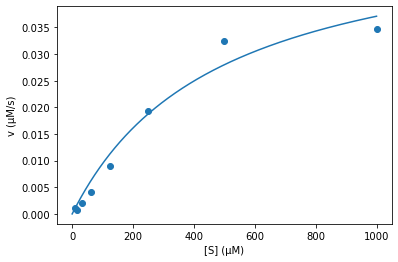

In [220]:
plt.scatter(sub_concs, bs_adk_avg_slopes)
x = np.linspace(0, 1000, 1000)
plt.plot(x, mm_model(x, params[0], params[1]))
plt.xlabel("[S] (µM)")
plt.ylabel("v (µM/s)")

In [270]:
e_conc = .565 * 1e-4

In [218]:
params

array([5.49742076e-02, 4.81332502e+02])

In [271]:
params[0] / e_conc

972.9948251531234

## Retrying bsADK MM with New Initial Slope Function

In [256]:
bs_adk_rep_1_slopes_2 = []
bs_adk_rep_2_slopes_2 = []

for rep, sub_conc in zip(bs_arr[0::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope2(time_arr, rep, bs_1mm_cutoff)
    bs_adk_rep_1_slopes_2.append(slope)

for rep, sub_conc in zip(bs_arr[1::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope2(time_arr, rep, bs_1mm_cutoff)
    bs_adk_rep_2_slopes_2.append(slope)

In [257]:
bs_adk_avg_slopes_2 = np.mean([bs_adk_rep_1_slopes_2, bs_adk_rep_2_slopes_2], axis=0)
errs_2 = np.std([bs_adk_rep_1_slopes_2, bs_adk_rep_2_slopes_2], axis=0)

Text(0, 0.5, 'v (µM/s)')

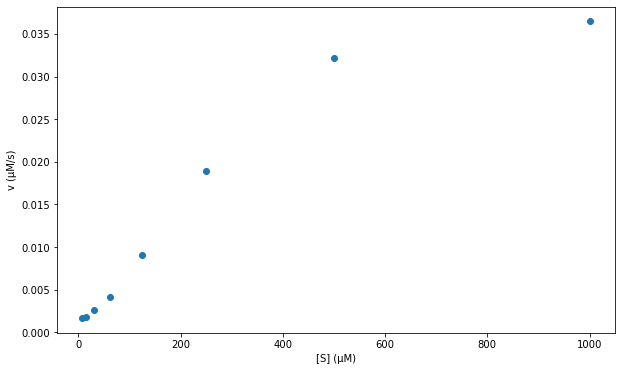

In [258]:
plt.figure(figsize=(10,6))
plt.scatter(sub_concs, bs_adk_avg_slopes_2)
plt.xlabel("[S] (µM)")
plt.ylabel("v (µM/s)")

In [266]:
params_2, _ = curve_fit(mm_model, sub_concs, bs_adk_avg_slopes_2)

In [264]:
print(errs_2)

[3.10648982e-03 9.78216468e-05 7.42857135e-05 4.57843753e-04
 1.12364401e-04 1.59561721e-04 2.44596842e-05 6.15988498e-05]


Text(0, 0.5, 'v (µM/s)')

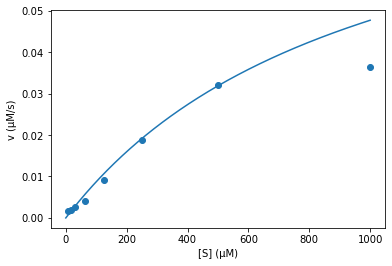

In [265]:
plt.scatter(sub_concs, bs_adk_avg_slopes_2)
x = np.linspace(0, 1000, 1000)
plt.plot(x, mm_model(x, params_2[0], params_2[1]))
plt.xlabel("[S] (µM)")
plt.ylabel("v (µM/s)")

# gsADK Plotting

In [279]:
gs_df = df.iloc[:, 21:39].T
gs_df

,0,1,2,3,4,5,6,7,8,9,...,299,300,301,302,303,304,305,306,307,308
C1,5885,5989,6075,6135,6234,6362,6410,6512,6671,6694,...,27814,28384,28237,28026,28002,27948,27733,28673,28154,28423
C2,6083,6179,6287,6302,6442,6598,6532,6631,6778,6898,...,26828,27416,27042,27085,27120,27121,26934,27190,27398,27331
C3,4542,4574,4723,4815,4846,4964,5025,5116,5290,5357,...,24021,24511,24283,24437,24516,24472,24495,24741,25024,24543
C4,4377,4540,4652,4716,4803,4978,4929,5093,5193,5223,...,23641,23849,23788,24018,23771,24078,23953,24195,24252,23858
C5,3637,3721,3737,3863,3947,4023,4055,4121,4218,4322,...,18994,19092,19060,19220,19045,19204,19078,19266,19235,19065
C6,3597,3642,3727,3810,3890,3938,3988,4051,4161,4127,...,18410,18624,18542,18292,18564,18405,18334,18495,18504,18581
C7,3186,3233,3282,3339,3384,3427,3509,3518,3578,3620,...,14465,14683,14548,14263,14371,14461,14348,14441,14506,14376
C8,3481,3642,3769,3947,4023,3955,4140,4083,4227,4030,...,13674,14134,13763,13928,13850,13919,13964,13781,13864,13779
C9,2850,2866,2898,2969,2945,2977,3069,3050,3077,3122,...,10063,9998,10078,9906,10018,10050,9913,10141,10138,10110
C10,2806,2856,2899,2898,2917,2952,2923,2938,2916,2960,...,9157,9087,9178,9110,9156,9041,9023,9371,9233,9235


In [230]:
gs_arr = np.array(gs_df)

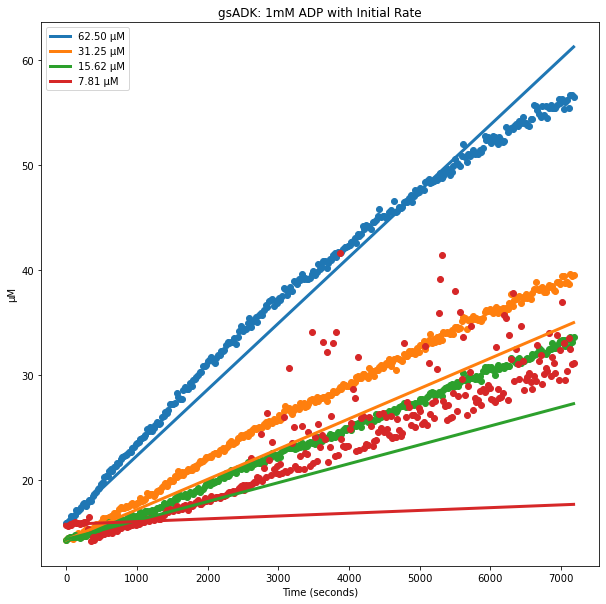

In [236]:
fig = plt.figure(figsize=(10,10))
    
for rep, sub_conc in zip(gs_arr[0::2][4:] / 179, sub_concs[4:]):
    slope, intercept, score = compute_initial_reaction_slope(time_arr, rep, sub_conc, .5)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("gsADK: 1mM ADP with Initial Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()